# Tarea 3: Polars frente a Pandas

Prediccion binaria de retrasos de vuelos con 539,383 registros de Kaggle. El notebook presenta el pipeline, la evidencia experimental y los modelos sin resultados simulados.

**Computación Paralela - Lead University**


## Preparacion

El dataset debe estar en `data/Airlines.csv`. El pipeline principal esta modularizado en `src/polars_pipeline.py` y genera resultados reproducibles en `results/` y `figures/`.

In [1]:
from pathlib import Path
import sys, subprocess, json
import polars as pl
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
DATA = ROOT / 'data' / 'Airlines.csv'
print('Raiz:', ROOT)
print('Dataset disponible:', DATA.exists())
print('Polars:', pl.__version__, '| Pandas:', pd.__version__)

Raiz: c:\Users\carol\OneDrive - LEAD University\Trabajos\Computacion Paralela\CP_Polars Airline_dataset\tarea3_airlines
Dataset disponible: True
Polars: 1.44.1 | Pandas: 3.0.5


## Validacion del dataset y EDA con Polars

In [2]:
df = pl.read_csv(DATA)
print('Dimensiones:', df.shape)
display(df.head())
display(df.null_count())
display(df.select(['Flight', 'DayOfWeek', 'Time', 'Length', 'Delay']).describe())
display(df.group_by('Delay').len().sort('Delay'))

Dimensiones: (539383, 9)


id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
i64,str,i64,str,str,i64,i64,i64,i64
1,"""CO""",269,"""SFO""","""IAH""",3,15,205,1
2,"""US""",1558,"""PHX""","""CLT""",3,15,222,1
3,"""AA""",2400,"""LAX""","""DFW""",3,20,165,1
4,"""AA""",2466,"""SFO""","""DFW""",3,20,195,1
5,"""AS""",108,"""ANC""","""SEA""",3,30,202,0


id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0


statistic,Flight,DayOfWeek,Time,Length,Delay
str,f64,f64,f64,f64,f64
"""count""",539383.0,539383.0,539383.0,539383.0,539383.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",2427.92863,3.929668,802.728963,132.202007,0.445442
"""std""",2067.429837,1.914664,278.045911,70.117016,0.497015
"""min""",1.0,1.0,10.0,0.0,0.0
"""25%""",712.0,2.0,565.0,81.0,0.0
"""50%""",1809.0,4.0,795.0,115.0,0.0
"""75%""",3745.0,5.0,1035.0,162.0,1.0
"""max""",7814.0,7.0,1439.0,655.0,1.0


Delay,len
i64,u32
0,299119
1,240264


No se observaron valores faltantes. El pipeline conserva imputacion por moda para categoricas y mediana para numericas como estrategia defensiva. Se filtran rangos invalidos y se crean Hour, IsWeekend, DurationBin, variables escaladas, encodings deterministas y AirlineFrequency.

## Ejecucion reproducible

In [3]:
subprocess.run(
    [sys.executable, str(ROOT / "src" / "polars_pipeline.py")],
    cwd=ROOT,
    check=True,
)

subprocess.run(
    [sys.executable, str(ROOT / "src" / "analysis.py")],
    cwd=ROOT,
    check=True,
)

CompletedProcess(args=['c:\\Users\\carol\\OneDrive - LEAD University\\Trabajos\\Computacion Paralela\\CP_Polars Airline_dataset\\tarea3_airlines\\.venv\\Scripts\\python.exe', 'c:\\Users\\carol\\OneDrive - LEAD University\\Trabajos\\Computacion Paralela\\CP_Polars Airline_dataset\\tarea3_airlines\\src\\analysis.py'], returncode=0)

## Benchmark y speedup

Operation,PolarsSeconds,PandasSeconds,Speedup
str,f64,f64,f64
"""Read""",0.016504,0.45139,27.351029
"""Filter""",0.006638,0.014449,2.176758
"""Aggregation""",0.003385,0.014884,4.397129
"""Join""",0.011249,0.077757,6.912391
"""FeatureEngineering""",0.060587,0.464967,7.674391
"""TotalPipeline""",0.073159,0.915378,12.512137


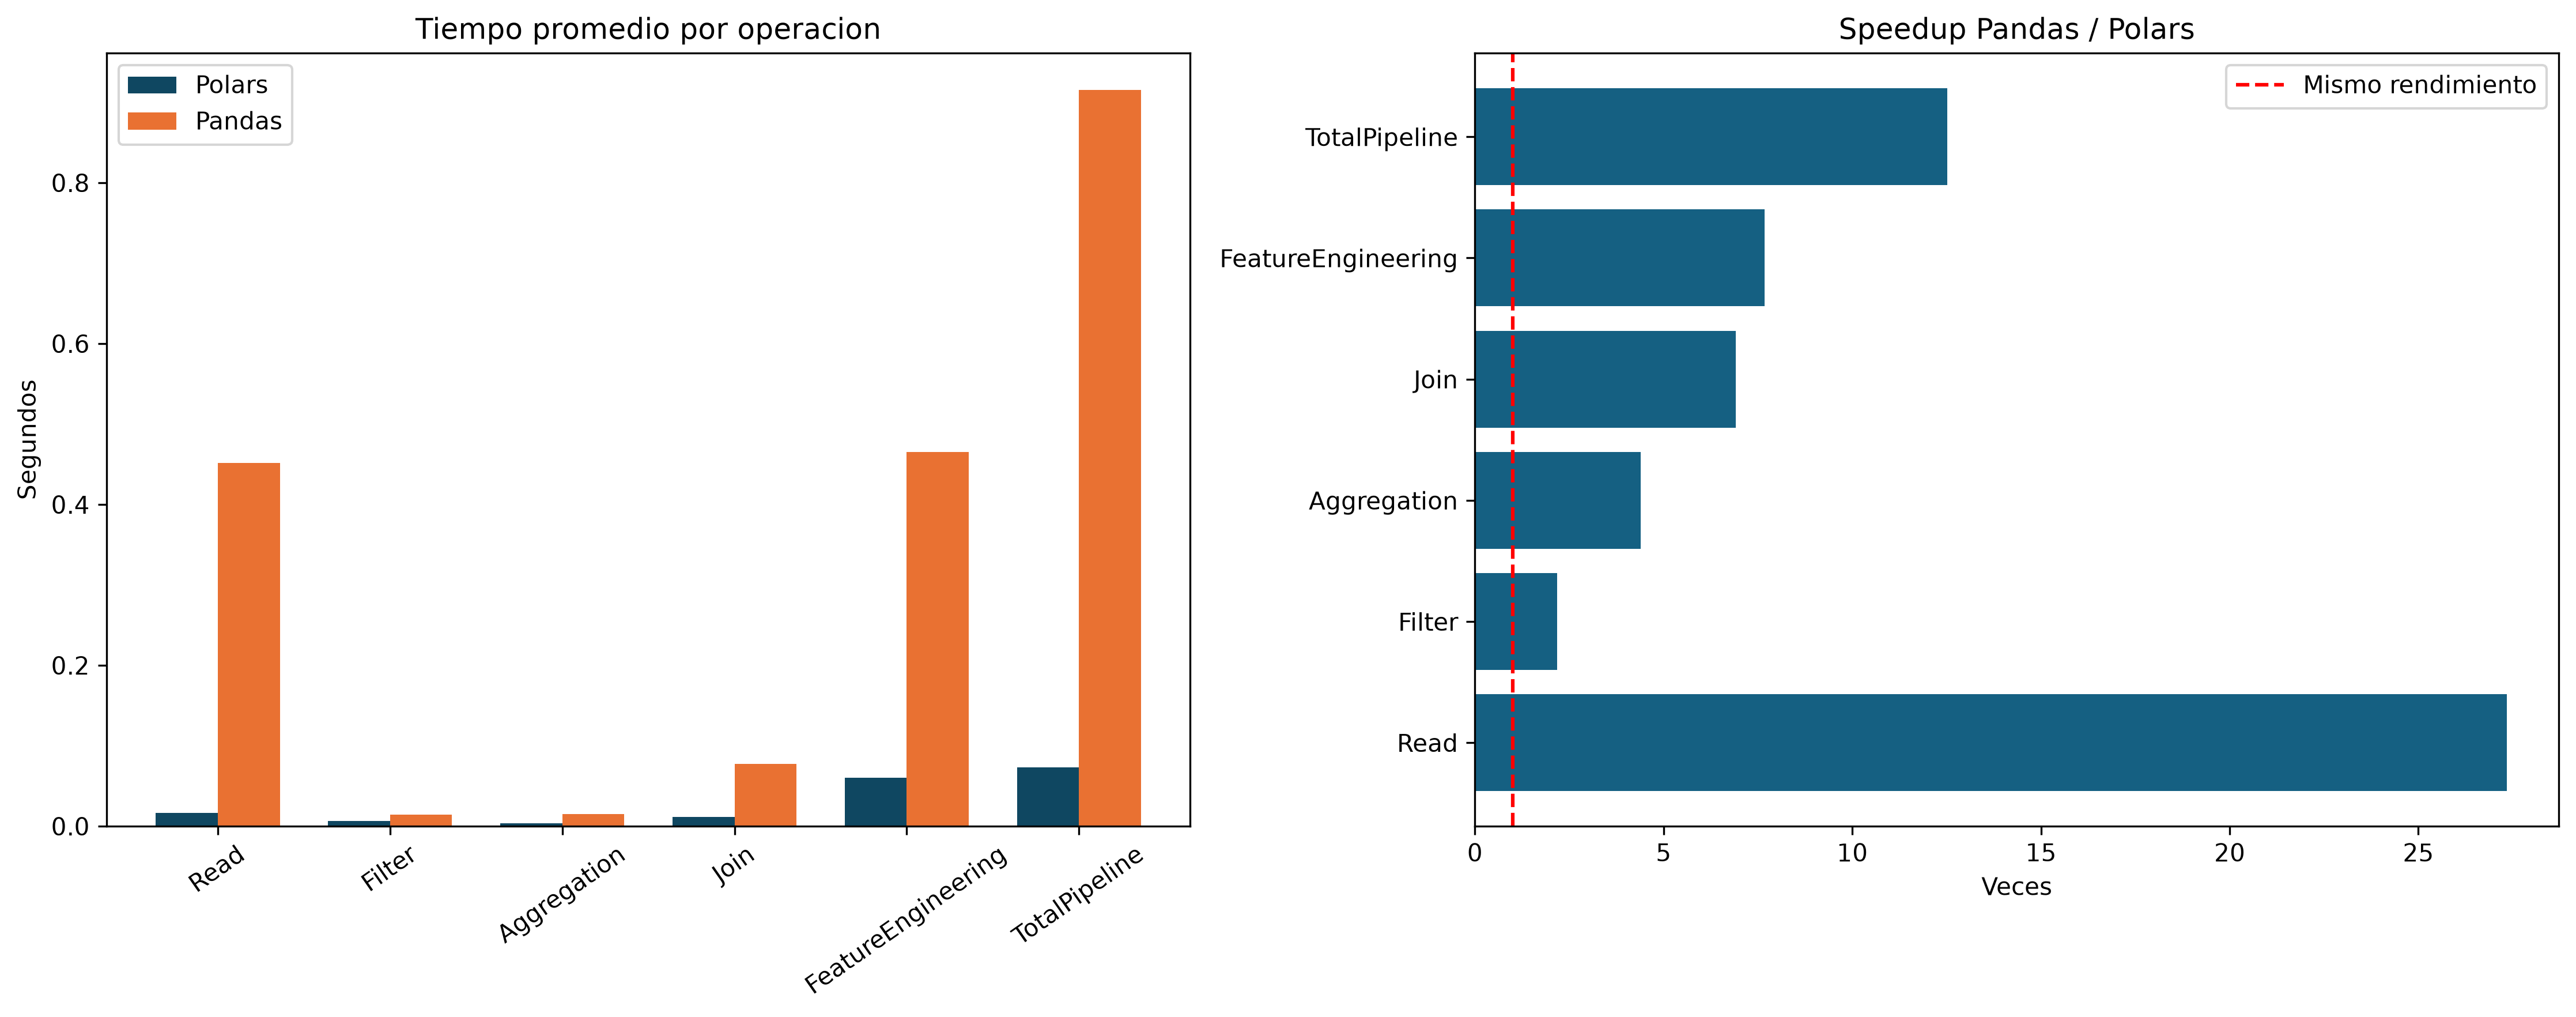

In [4]:
benchmark = pl.read_csv(ROOT / 'results' / 'benchmark_results.csv')
display(benchmark)
display(Image(filename=str(ROOT / 'figures' / 'benchmark_comparison.png')))


## Escalabilidad y lazy execution

Fraction,Rows,PolarsSeconds,PandasSeconds,Speedup
i64,i64,f64,f64,f64
25,134845,0.028096,0.117329,4.176022
50,269691,0.044606,0.235812,5.286616
75,404537,0.043802,0.343815,7.849265
100,539383,0.08189,0.461692,5.63792


Mode,Seconds,PeakMemoryIncreaseMB
str,f64,f64
"""read_csv""",0.02628,18.839844
"""scan_csv_collect""",0.026291,24.21875


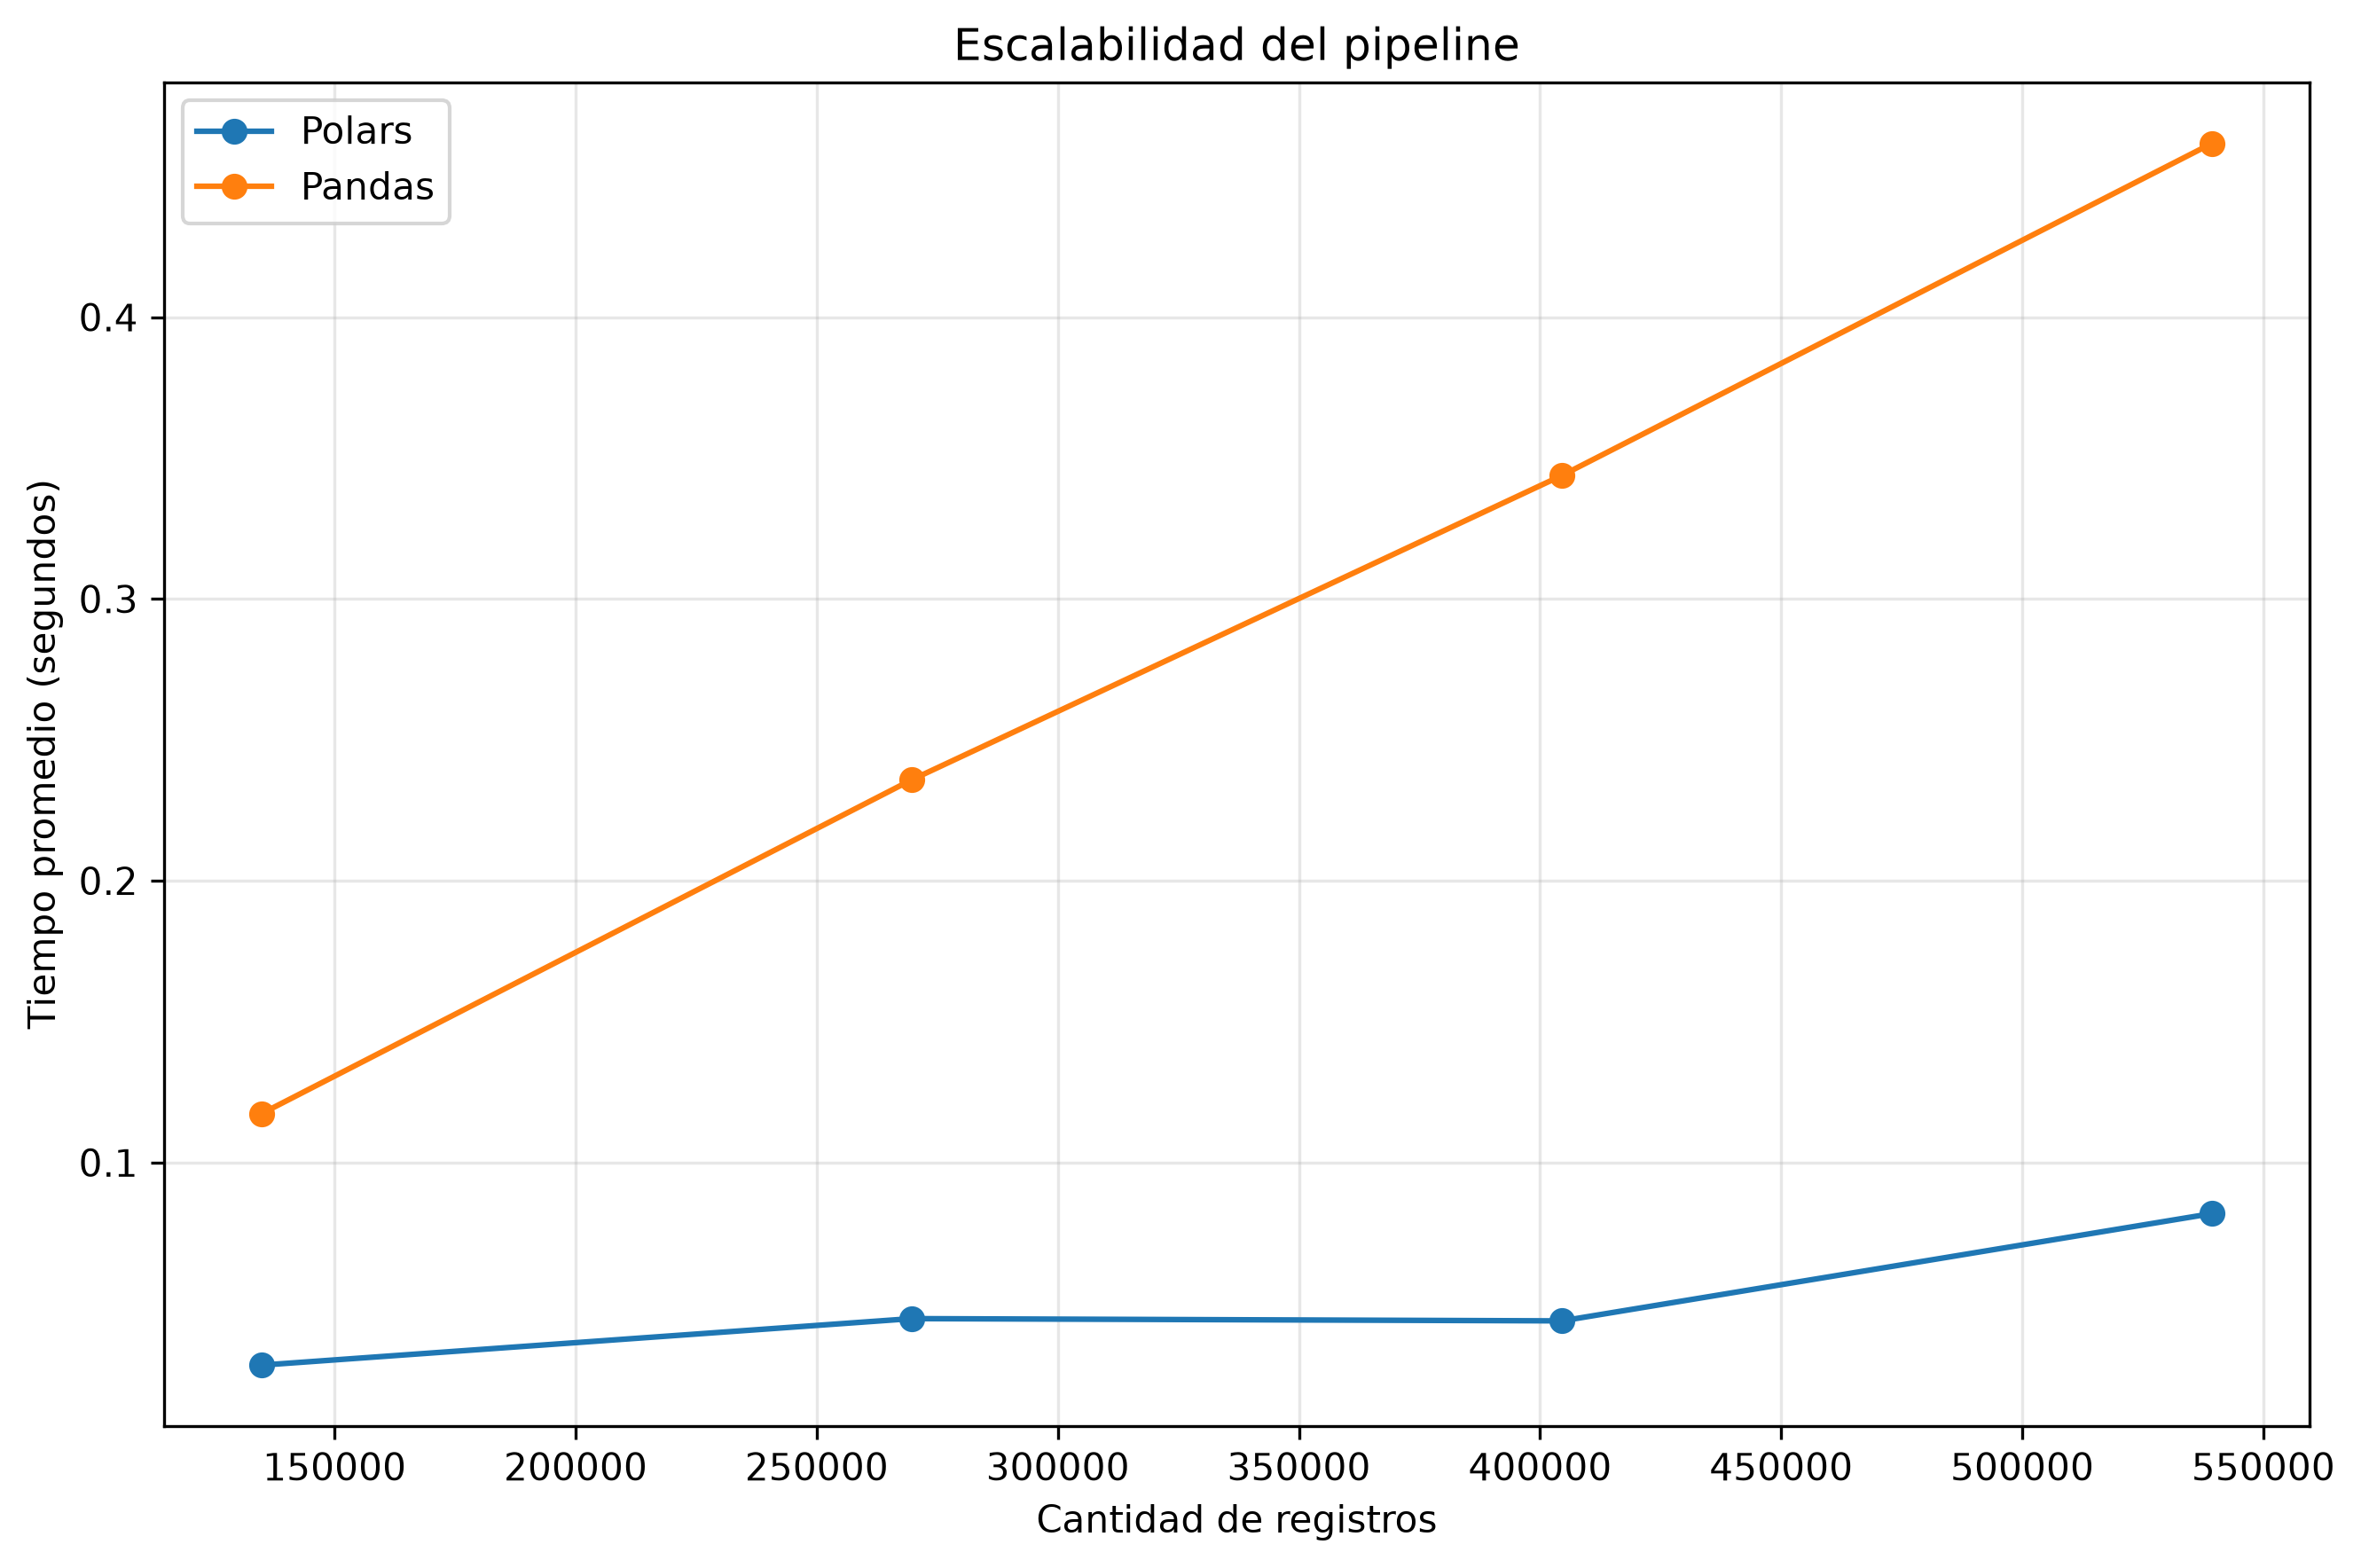

In [5]:
scalability = pl.read_csv(ROOT / 'results' / 'scalability_results.csv')
lazy = pl.read_csv(ROOT / 'results' / 'lazy_execution_results.csv')
display(scalability)
display(lazy)
display(Image(filename=str(ROOT / 'figures' / 'scalability.png')))

## Modelos predictivos

Model,Accuracy,F1Weighted,PrecisionWeighted,RecallWeighted,AUC,TrainingSeconds
str,f64,f64,f64,f64,f64,f64
"""Logistic Regression""",0.625635,0.615887,0.622434,0.625635,0.65626,0.487988
"""Random Forest""",0.616968,0.616391,0.615999,0.616968,0.657638,8.201279
"""XGBoost""",0.661973,0.651208,0.663244,0.661973,0.713374,2.858556


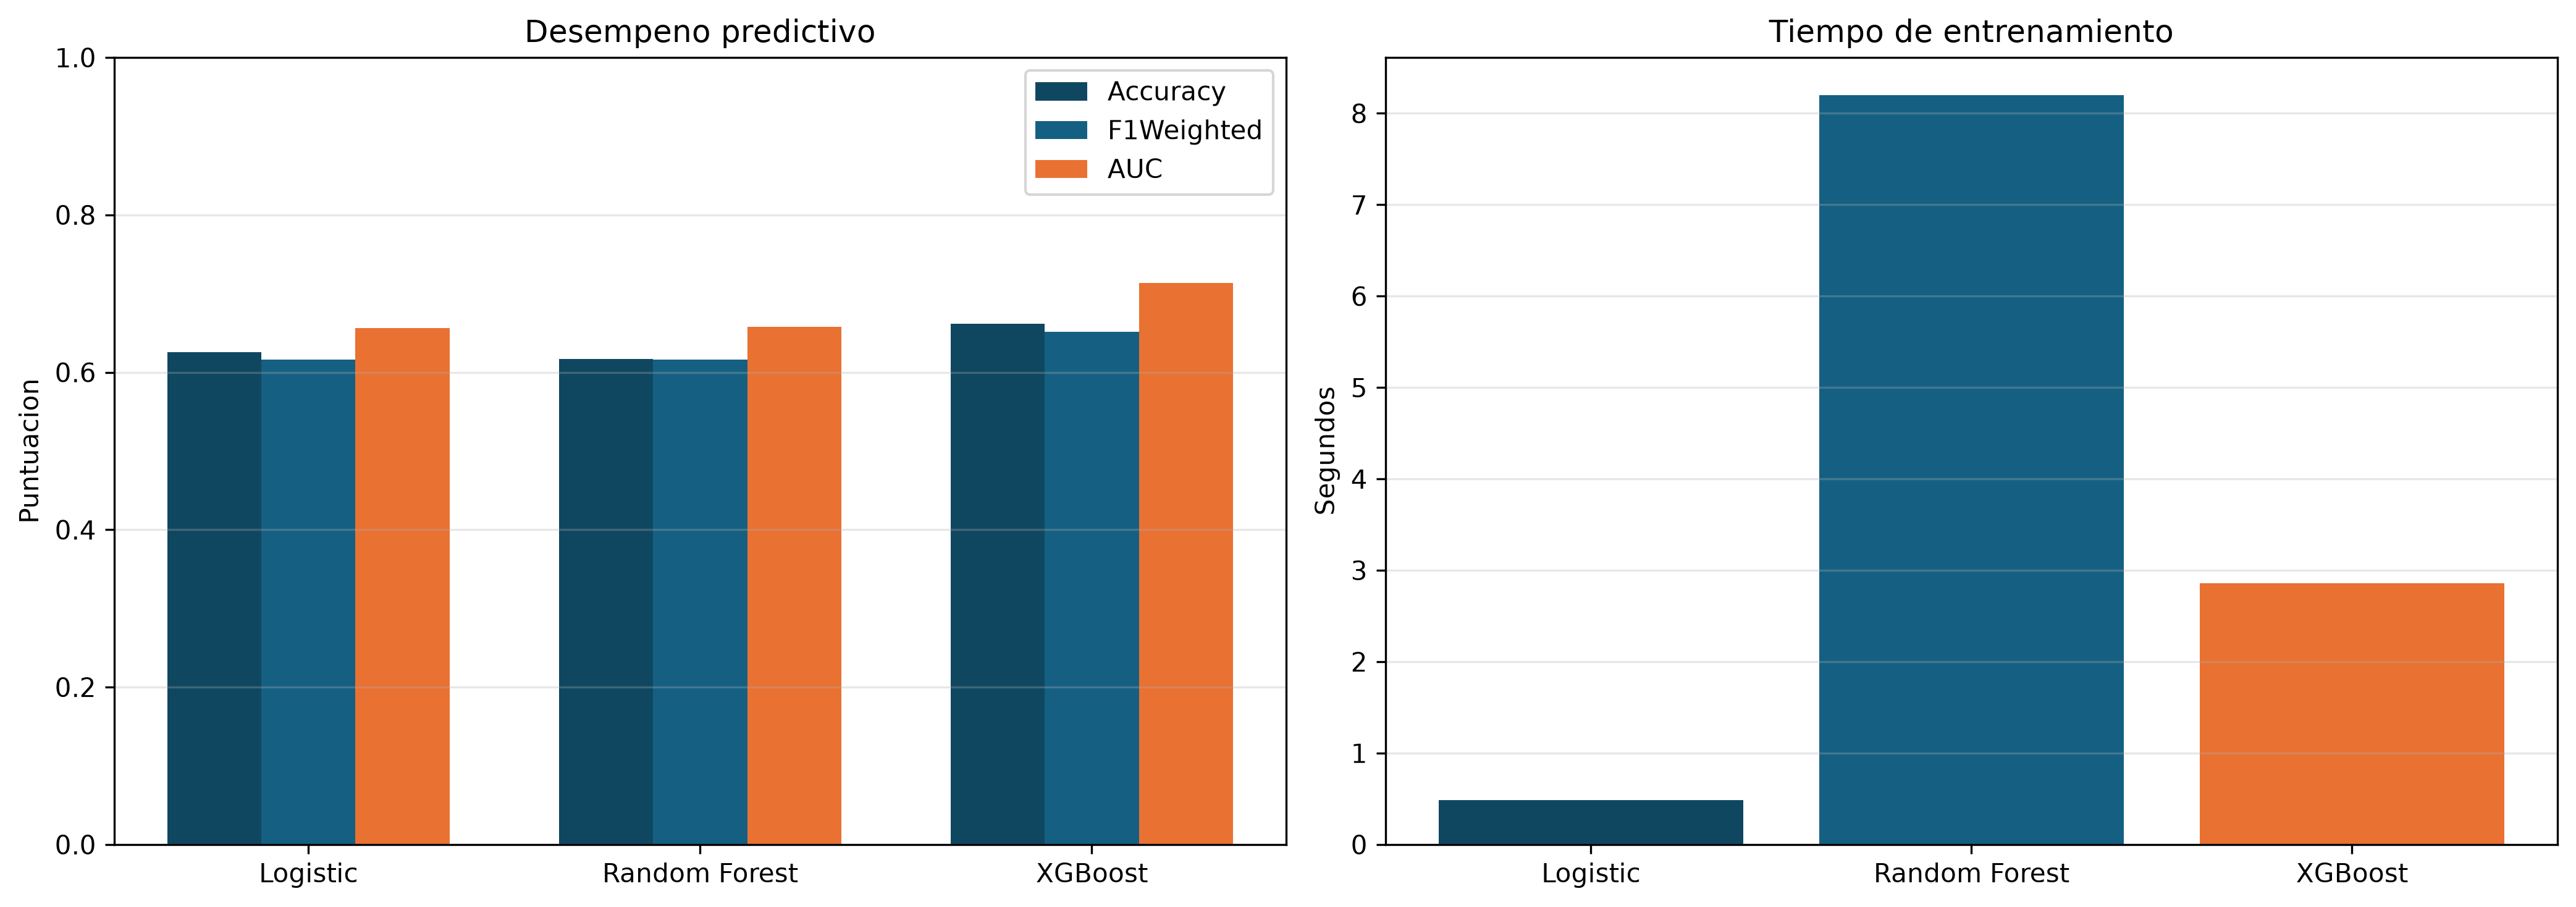

Mejor modelo: XGBoost | AUC: 0.7134


In [6]:
models = pl.read_csv(ROOT / 'results' / 'model_results.csv')
display(models)
display(Image(filename=str(ROOT / 'figures' / 'model_comparison.png')))
best = models.sort(['AUC', 'F1Weighted'], descending=[True, True]).row(0, named=True)
print('Mejor modelo:', best['Model'], '| AUC:', round(best['AUC'], 4))

## Analisis y conclusiones

In [7]:
display(Markdown((ROOT / 'report' / 'analysis_report.md').read_text(encoding='utf-8')))

# Tarea 3: Polars vs Pandas

**Curso:** Computación Paralela  
**Profesor:** Johansell Villalobos Cubillo  
**Estudiante:** Carolina Salas  
**Institución:** LEAD University  
**Fecha:** Junio 2026

## Análisis de resultados: Polars frente a Pandas

## Resumen experimental

El dataset publico de Kaggle contiene 539,383 registros y 9 columnas, incluida la variable objetivo binaria `Delay`. Se identificaron 0 valores faltantes. La clase 0 contiene 299,119 registros y la clase 1 contiene 240,264, por lo que existe una diferencia moderada, pero no un desbalance extremo.

El entorno utilizado fue Windows-10-10.0.26200-SP0, con 10 nucleos fisicos, 16 nucleos logicos y 31.63 GB de RAM. El archivo ocupa 17.66 MB. Se utilizaron Polars 1.44.1 y Pandas 3.0.5. Cada operacion del benchmark se midio 5 veces y se reporto el promedio.

## Preguntas de analisis

### 1. ¿Que ventajas se observaron al utilizar Polars?

Polars redujo el tiempo en todas las operaciones medidas. El pipeline total paso de 0.9154 segundos en Pandas a 0.0732 segundos en Polars, equivalente a un speedup de 12.51x. La API de expresiones permitio realizar filtrado, escalado, binning, encoding, agregaciones y joins sin ciclos sobre las filas.

### 2. ¿Que operaciones obtuvieron el mayor speedup?

La mayor aceleracion se observo en `Read`, con 27.35x. El resultado muestra que la arquitectura columnar y la implementacion paralela de Polars producen una diferencia especialmente clara en esta operacion.

### 3. ¿En cuales operaciones la diferencia fue pequena?

La menor diferencia se presento en `Filter`, aunque Polars todavia obtuvo 2.18x. Esto indica que las operaciones simples tienen menor margen de optimizacion que un pipeline con varias transformaciones encadenadas.

### 4. ¿Que beneficios aporto Lazy Execution?

En este experimento, lazy execution no mejoro el resultado. `read_csv` tardo 0.0263 segundos y aumento el pico de memoria aproximadamente 18.84 MB; `scan_csv().collect()` tardo 0.0263 segundos y aumento el pico aproximadamente 24.22 MB. El pipeline evaluado es corto, utiliza todas las columnas requeridas por la agregacion y el archivo solo ocupa 17.66 MB, por lo que el costo de construir y optimizar el plan supera el ahorro potencial. Lazy execution seria mas beneficioso en pipelines largos, con proyeccion de pocas columnas o filtros capaces de descartar gran parte de los datos.

### 5. ¿Que limitaciones se encontraron en Polars?

La sintaxis y algunos nombres de metodos cambian entre versiones, por lo que fue necesario adaptar el codigo a Polars 1.44.1. Ademas, scikit-learn trabaja principalmente con arreglos NumPy o DataFrames de Pandas, de modo que los datos finales debieron convertirse antes del entrenamiento. Las mediciones de memoria de operaciones nativas tambien son aproximadas porque se basan en el RSS del proceso.

### 6. ¿Que ventajas mantiene Pandas?

Pandas conserva un ecosistema muy amplio, abundante documentacion y compatibilidad directa con numerosas bibliotecas estadisticas y de aprendizaje automatico. Para datasets pequenos o exploraciones sencillas, su familiaridad puede ser mas importante que una diferencia reducida de tiempo.

### 7. ¿La aceleracion justifica migrar un proyecto existente?

Para este caso, una aceleracion total de 12.51x si justifica considerar Polars cuando el pipeline se ejecuta repetidamente o tiene restricciones de tiempo. Una migracion real debe valorar tambien el costo de reescribir, validar y mantener el codigo. No se recomienda migrar un proyecto pequeno solo por preferencia tecnologica.

### 8. ¿Como afecto el tamano del dataset al beneficio?

Con 134,845 registros, el speedup fue 4.18x. Con 539,383 registros, fue 5.64x. La ventaja crecio inicialmente conforme aumento el volumen y luego se estabilizo, lo que evidencia que Polars aprovecha mejor el procesamiento columnar cuando el costo de la operacion supera la sobrecarga inicial.

### 9. ¿Que modelo produjo el mejor desempeno predictivo?

El mejor modelo fue XGBoost, con Accuracy de 0.6620, F1 weighted de 0.6512 y AUC de 0.7134. Su ventaja sugiere relaciones no lineales e interacciones entre aerolinea, ruta, horario, dia y duracion que Logistic Regression no captura completamente.

### 10. ¿Que recomendaciones se darian para proyectos futuros?

Se recomienda usar Polars en pipelines repetitivos o con cientos de miles de filas, medir varias repeticiones en lugar de basarse en una sola ejecucion y evaluar lazy execution segun la complejidad real del flujo. En Machine Learning deben compararse varias metricas y no solamente Accuracy. Para una aplicacion operacional se deberian incorporar variables como clima, congestion y retrasos historicos, y validar el modelo con una division temporal.

## Conclusiones

Los experimentos muestran que Polars fue mas rapido que Pandas en las seis operaciones comparadas y alcanzo 12.51x en el pipeline completo. La escalabilidad confirma que la ventaja se mantiene al aumentar el numero de registros. Sin embargo, lazy execution no fue superior en tiempo ni memoria para este flujo corto, lo cual demuestra que su beneficio depende del plan de consulta y no debe asumirse automaticamente. En prediccion, XGBoost obtuvo el mejor balance de Accuracy, F1 y AUC. Por tanto, Polars es recomendable para el procesamiento de este dataset, mientras que la eleccion del modelo debe basarse en evidencia predictiva y en las necesidades de interpretabilidad.


Las cifras finales y la selección del mejor modelo se generan dinámicamente a partir de los archivos de `results/`. La conveniencia de lazy execution depende de la complejidad del plan y no debe asumirse antes de medirla.